# FraudShield-AI

## Exploratory Data Analysis (EDA)

### Objective

The purpose of this notebook is to explore and understand the Credit Card Fraud Detection dataset before building a machine learning model.

During this analysis, we will:

- Load and inspect the dataset
- Examine its structure and feature types
- Identify missing values and duplicate records
- Analyze the distribution of fraudulent and legitimate transactions
- Identify preprocessing steps required for model development

The insights gained during this phase will guide the preprocessing pipeline and neural network architecture developed in later stages of the project.

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option("display.max_columns", None)

# Plot styling
plt.style.use("ggplot")

# Load the Dataset

The first step in any machine learning project is loading the dataset into memory. Once loaded, we can inspect its structure, verify that it imported correctly, and begin exploring its characteristics.

In [4]:
# Load the dataset
df = pd.read_csv("../data/raw/creditcard.csv")

# Display the first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Dataset Dimensions

## Objective

Understanding the size of the dataset provides valuable context before beginning analysis.

Knowing the number of rows and columns helps estimate computational requirements and provides an overview of the available information.

In [5]:
# Display the number of rows and columns
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (284807, 31)


# Dataset Features

## Objective

Understanding the available features allows us to identify the information that will be used by the neural network during training.

This step also helps distinguish input features from the target variable.

In [6]:
# Display all column names
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

# Dataset Structure

## Objective

The purpose of this section is to inspect the structure of the dataset.

Specifically, we want to determine:

- The data type of each feature
- Whether any features contain missing values
- Whether the dataset is ready for preprocessing

Understanding the dataset structure helps identify any cleaning or transformations required before training the neural network.

In [7]:
# Display information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Interpretation

The dataset contains 31 columns consisting entirely of numerical features (`float64` and `int64`).

No missing values were identified, indicating that the dataset is complete and does not require imputation.

Since all input features are already numerical, no categorical encoding will be necessary during preprocessing. This simplifies the machine learning pipeline and allows us to focus on feature scaling and class imbalance.

# Statistical Summary

## Objective

The purpose of this section is to generate descriptive statistics for the dataset.

Summary statistics help us understand the distribution, scale, and range of the numerical features. These insights will guide preprocessing decisions, such as feature scaling and normalization, before training the neural network.

In [8]:
# Display descriptive statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Interpretation

The descriptive statistics provide an overview of each numerical feature's distribution.

The anonymized PCA features are generally centered around zero with relatively small ranges, while the Amount feature varies much more significantly.

Because the features are on different scales, feature scaling will be necessary before training the neural network.

# Missing Values

## Objective

Machine learning models require complete data.

This section checks whether any features contain missing values that must be handled before training.

In [9]:
# Count missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Interpretation

No missing values were found in the dataset.

Since every feature contains complete information, no imputation or row removal is required before model training.

# Duplicate Records

## Objective

Duplicate observations can bias machine learning models and negatively affect evaluation metrics.

This section identifies whether duplicate transactions exist within the dataset.

In [10]:
# Count duplicate rows
duplicates = df.duplicated().sum()

print(f"Duplicate Transactions: {duplicates}")

Duplicate Transactions: 1081


# Target Variable Distribution

## Objective

Understanding the distribution of the target variable is critical for selecting appropriate evaluation metrics and training strategies.

Fraud detection datasets are typically highly imbalanced because fraudulent transactions occur far less frequently than legitimate transactions.

In [11]:
# Count the number of transactions in each class
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [15]:
# Display class percentages
class_percentages = (df["Class"].value_counts(normalize=True) * 100).round(2)

print(class_percentages)

Class
0    99.83
1     0.17
Name: proportion, dtype: float64


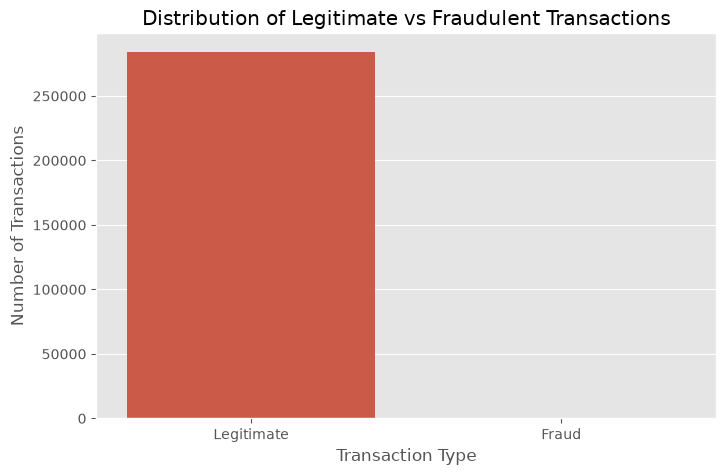

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate vs Fraudulent Transactions")

plt.xlabel("Transaction Type")

plt.ylabel("Number of Transactions")

plt.xticks([0,1],["Legitimate","Fraud"])

plt.show()

## Interpretation

The visualization confirms that the dataset is extremely imbalanced.

The overwhelming majority of transactions are legitimate, while fraudulent transactions represent only a very small fraction of the dataset.

This class imbalance presents a significant challenge for machine learning because a model could achieve very high accuracy simply by predicting every transaction as legitimate.

To properly evaluate the model, metrics such as Precision, Recall, F1-Score, and ROC-AUC will be emphasized rather than relying solely on accuracy.